# 01 · Image resizing

Compare image sizes at scales 0.25, 0.5, 2, and 4 while preserving color and inspecting interpolation.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

Output width and height are rounded to the nearest integer and clamped to at least one pixel. Downsampling uses area interpolation; upsampling uses cubic interpolation. All panels use comparable display areas so resolution changes must be interpreted together with their pixel dimensions.

In [2]:
SCALES = (0.25, 0.5, 2.0, 4.0)
def resize_image(image, scale):
    if scale <= 0:
        raise ValueError("Scale must be positive")
    height, width = image.shape[:2]
    size = (max(1, round(width * scale)), max(1, round(height * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    return cv2.resize(image, size, interpolation=interpolation)

## 3. Results on both photographs

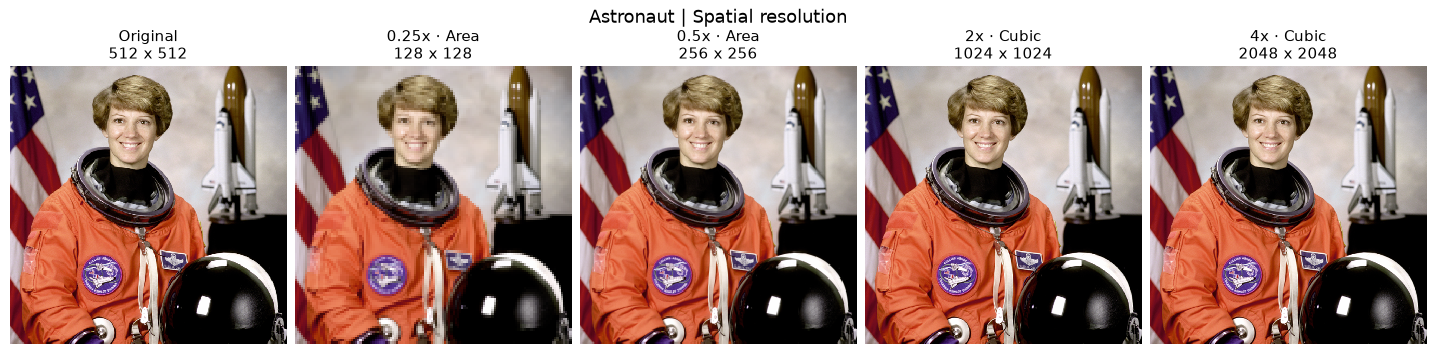

| Scale | Width | Height | Interpolation |
| --- | --- | --- | --- |
| 0.25x | 128 | 128 | Area |
| 0.5x | 256 | 256 | Area |
| 2x | 1024 | 1024 | Cubic |
| 4x | 2048 | 2048 | Cubic |

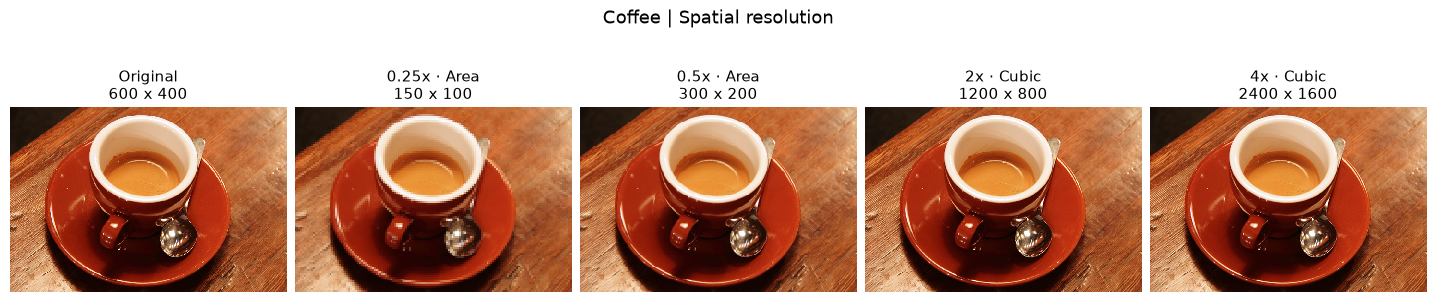

| Scale | Width | Height | Interpolation |
| --- | --- | --- | --- |
| 0.25x | 150 | 100 | Area |
| 0.5x | 300 | 200 | Area |
| 2x | 1200 | 800 | Cubic |
| 4x | 2400 | 1600 | Cubic |

In [3]:
for name, photo in images.items():
    image = photo["rgb"]
    resized = {scale: resize_image(image, scale) for scale in SCALES}
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.8), layout="constrained")
    show_image(axes[0], image, f"Original\n{image.shape[1]} x {image.shape[0]}")
    rows = []
    for ax, (scale, result) in zip(axes[1:], resized.items()):
        method = "Area" if scale < 1 else "Cubic"
        show_image(ax, result, f"{scale:g}x · {method}\n{result.shape[1]} x {result.shape[0]}")
        expected = (max(1, round(image.shape[0] * scale)), max(1, round(image.shape[1] * scale)), 3)
        assert result.shape == expected and result.dtype == np.uint8
        rows.append([f"{scale:g}x", result.shape[1], result.shape[0], method])
    fig.suptitle(name.title() + " | Spatial resolution", fontsize=14)
    show_figure(fig)
    show_table(["Scale", "Width", "Height", "Interpolation"], rows)
    RESULTS[name] = {"original_shape": list(image.shape), "output_shapes": {str(s): list(r.shape) for s, r in resized.items()}}

## 4. Interpretation

Downsampling removes spatial detail. Upsampling adds interpolated samples and cannot recreate information that was absent from the input. A larger pixel count alone does not imply newly captured detail.

In [4]:
assert resize_image(np.zeros((1, 1, 3), dtype=np.uint8), 0.25).shape == (1, 1, 3)
assert resize_image(np.zeros((5, 7, 3), dtype=np.uint8), 0.5).shape == (2, 4, 3)
print("PASS: all eight photo resizes, output dtypes, and tiny/odd-dimension checks.")

PASS: all eight photo resizes, output dtypes, and tiny/odd-dimension checks.
